### Imports and plotting setting

In [1]:
import numpy as np
from scipy.optimize import fsolve, root

# import predefined functions wich solve the box model
import fct_BoxModel as fbm
import fct_BoxModel_qcst as fbm_qcst
import fct_BoxModel_velo as fbm_velo


import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv

from matplotlib import colors

from cmcrameri import cm as cmcra #berlin colormap

matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=128):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

lipari_cut = truncate_colormap(cmcra.lipari, minval=0.15, maxval=1.0, n=128)

### Open usefull datasets

In [2]:
inputs = xr.open_dataset("model_input_dataset.nc")
index_isf = inputs.Nisf.values
name_isf = inputs.name_isf.values
outputs = xr.open_dataset("model_output_dataset.nc")

### Define Default parameters

In [5]:
#PICO parameters
# Reese 2018
C_ref = 1e6 #m^6/s/kg
gammaT_ref = 2e-5 #m/s



#Vertical mixing
# ~Olbers & Hellmer 2010
kappa_diff_ref = 1e-7  # m/s
kappa_conv_ref = 1e-3 # m/s

#Polynia
g_ref = 20

# Continuous mixing
Lamb_ref = 0.3 #kg/m^3

#AABW
C2_ref = 4e6 #m^6/s/kg

#densities
rho_i = 910 #kg/m^3


r_ref = 0.8


#### Important line: choose your ice shelf (31=Amery)
index = 31


nbox = int(inputs.Nbox.sel(Nisf=index).values)
Ac = inputs.Ac.sel(Nisf=index).values #m^2
frac = inputs.frac.sel(Nisf=index).values
depth = inputs.depth.sel(Nisf=index).values

AABW_ref = False # If you want to use the AABW param
T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)

Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values) *2/3 # Interannual average, 2/3 factor because only march to october rates here
Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 *2/3  #m/s Interannual average, 2/3 factor because only march to october rates here
T0_ref = np.mean(inputs.T0.sel(Nisf=index).values)
S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

T0_series = inputs.T0.sel(Nisf=index).values
SeaIce_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values *rho_i*Omega_ref *2/3 *24*3600*365.25/1e12 #Gt/y 2/3 factor because only march to october rates here

# constant q parameterisation
q_ref = outputs.overt.sel(Nisf=index,regime='conv').values*1e6 #m^3/s (here we choose the convective value of q)

#velocity dependant \gamma_T^\star
Gamma_ref = gammaT_ref/q_ref #m^-2

arguments_PICO = [nbox, C_ref, gammaT_ref, Ac, Omega_ref, T0_ref, S0_ref, Ap_ref, kappa_conv_ref, g_ref, frac, depth, C2_ref, T_surf_ref, S_surf_ref, r, 'conv']
arguments_qcst = [nbox, q_ref, gammaT_ref, Ac, Omega_ref, T0_ref, S0_ref, Ap_ref, kappa_diff_ref, g_ref, frac, depth, C2_ref, T_surf_ref, S_surf_ref, AABW_ref]
arguments_velo = [nbox, C_ref, Gamma_ref, Ac, Omega_ref, T0_ref, S0_ref, Ap_ref, kappa_diff_ref, g_ref, frac, depth, C2_ref, T_surf_ref, S_surf_ref, AABW_ref]
arguments_smooth = [nbox, C_ref, gammaT_ref, Ac, Omega_ref, T0_ref, S0_ref, Ap_ref, kappa_diff_ref, kappa_conv_ref, Lamb_ref, g_ref, frac, depth, r_ref]

### Define functions to make melt maps for the step function parameterization of $\kappa$

In [9]:
def run_BoxModel(BoxModel, arguments, max_iter, guess, random_step):

    X, info, ier, msg = fsolve(BoxModel, guess, args = tuple(arguments), full_output=True,)
        
    if ier != 1: #management of non convergence cases
        incr = 0
        while ier != 1:
            X, info, ier, msg = fsolve(BoxModel, np.random.normal(guess,random_step), args = tuple(arguments), full_output=True)
            incr += 1
            if incr == max_iter:
                break

    return X, ier



def melt_map(BoxModel, arguments, Ap_list, T0_list, max_iter, random_step):

    guess_conv_0 = np.array([-1.9,T0_ref,S0_ref,S0_ref])
    guess_diff_0 = guess_conv_0
    
    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))
    
    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))
    
    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
   
    for m, Ap in enumerate(Ap_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0

        for n,T0 in enumerate(T0_list):
                
            ##################
            # Diffusive case #
            ##################
            arguments[7] = Ap
            arguments[5] = T0
            arguments[8] = kappa_diff_ref
            
            X_d, ier = run_BoxModel(BoxModel, arguments, max_iter, guess_diff, random_step)

            # Updating initial guess
            if ier == 1:
                guess_diff = X_d
            else:
                print('No convergence Diff',m,n)
            if m==0:
                guess_diff_0 = X_d


            #Filling the tab
            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = sigma_d[m,n]<0
                if stability_d[m,n]:
                    if BoxModel == fbm.BoxModel:
                        T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C_ref, gammaT_ref, Ac, frac, depth)
                    elif BoxModel == fbm_qcst.BoxModel_qcst:
                        T,S,melt = fbm_qcst.PICO_qcst(X_d[1],X_d[3],nbox,q_ref,gammaT_ref,Ac,frac,depth)
                        q = q_ref
                    else:
                        T,S,melt,q = fbm_velo.PICO_velo(X_d[1],X_d[3],nbox,C_ref,Gamma_ref,Ac,frac,depth)
                
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                sigma_d[m,n] = np.nan

            ###################
            # Convective case #
            ###################
            arguments[7] = Ap
            arguments[5] = T0
            arguments[8] = kappa_conv_ref

            X_c, ier = run_BoxModel(BoxModel,arguments, max_iter, guess_conv, random_step)
        
            # Updating initial guess
            if ier == 1:
                guess_conv = X_c
            else:
                print('No convergence Conv',m,n)
            if m==0:
                guess_conv_0 = X_c

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = sigma_c[m,n]>0
                if stability_c[m,n]:
                    if BoxModel == fbm.BoxModel:
                        T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C_ref, gammaT_ref, Ac, frac, depth)
                    elif BoxModel == fbm_qcst.BoxModel_qcst:
                        T,S,melt = fbm_qcst.PICO_qcst(X_c[1],X_c[3],nbox,q_ref,gammaT_ref,Ac,frac,depth)
                        q = q_ref
                    else:
                        T,S,melt,q = fbm_velo.PICO_velo(X_c[1],X_c[3],nbox,C_ref,Gamma_ref,Ac,frac,depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                sigma_c[m,n] = np.nan

    bistable = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)

    return melt_d, melt_c, sigma_d, sigma_c, stability_d, stability_c, bistable

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def bistable_size(bistable,T0_list,T0_ref,Ap_list):
    idx = find_nearest(T0_list,T0_ref)
    bist_arg = np.where(bistable[:,idx].mask == False)[0]
    Apbmin = Ap_list[bist_arg[0]]
    Apbmax = Ap_list[bist_arg[-1]]
    delta_Ap = Apbmax-Apbmin
    return Apbmin, Apbmax, delta_Ap

### Define functions to make melt maps for the smooth parameterization of $\kappa$

In [7]:
import imp
imp.reload(fbm)

def melt_map_smooth(arguments, Ap_list, T0_list, max_iter, random_step, tol):

    guess_fw_0 = np.array([-1.9,T0_ref,S0_ref,S0_ref])
    guess_bw_0 = guess_fw_0
    
    melt_fw = np.zeros((Npoint,Npoint))
    melt_bw = np.zeros((Npoint,Npoint))
    
    sigma_fw = np.zeros((Npoint,Npoint))
    sigma_bw = np.zeros((Npoint,Npoint))
   
    
    for n,T0 in enumerate(T0_list):
        
        guess_fw = guess_fw_0
        guess_bw = guess_bw_0


        ##################
        #     Forward    #
        ##################
        for m, Ap in enumerate(Ap_list):
            arguments[7] = Ap
            arguments[5] = T0
            
            X, ier = run_BoxModel(fbm.BoxModel_continuous_kappa,arguments, max_iter, guess_fw, random_step)

            # Updating initial guess
            if ier == 1:
                guess_fw = X
                if m==0:
                    guess_fw_0 = X

                sigma_fw[m,n] = fbm.compute_Sigma(X)
                Tc,Sc,melt,q = fbm.PICO(X[1], X[3], nbox, C_ref, gammaT_ref, Ac, frac, depth)
                m_avg = fbm.compute_m_avg(melt,frac,nbox)
                melt_fw[m,n] = m_avg 
            
            else:
                print('No convergence FW',m,n)
                sigma_fw[m,n] = np.nan
                melt_fw[m,n] = np.nan
                #sigma_d_0_fw[m,n] = np.nan


        ###################
        #     Backward    #
        ###################
        for m, Ap in enumerate(np.flip(Ap_list)):
            m = Npoint-m-1
                    
            arguments[7] = Ap
            arguments[5] = T0
            
            X, ier = run_BoxModel(fbm.BoxModel_continuous_kappa,arguments, max_iter, guess_bw, random_step)

            # Updating initial guess
            if ier == 1:
                guess_bw = X
                if m==Npoint-1:
                    guess_bw_0 = X

                sigma_bw[m,n] = fbm.compute_Sigma(X)
                Tc,Sc,melt,q = fbm.PICO(X[1], X[3], nbox, C_ref, gammaT_ref, Ac, frac, depth)
                m_avg = fbm.compute_m_avg(melt,frac,nbox)
                melt_bw[m,n] = m_avg 
            
            else:
                print('No convergence BW',m,n)
                sigma_bw[m,n] = np.nan
                melt_bw[m,n] = np.nan
                sigma_d_0_bw[m,n] = np.nan

    #monostable = np.ma.masked_where(np.abs(sigma_fw-sigma_bw)>tol, melt_fw)
    bistable = np.ma.masked_where(np.abs(sigma_fw-sigma_bw)<tol, np.ones((Npoint,Npoint))*0.25)

    return melt_fw, melt_bw, bistable, sigma_fw, sigma_bw

### plots cavity params

<function BoxModel_qcst at 0x7ffa42068e50>
136.41420563259763 Gt/y


/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025/fct_BoxModel.py:44: RuntimeWarning: invalid value encountered in sqrt
  x0 = -g1[0]/(2*C*rho_star*(beta*s-alpha))+np.sqrt((g1[0]/(2*C*rho_star*(beta*s-alpha)))**2-g1[0]*T_st_0/(C*rho_star*(beta*s-alpha)))


<function BoxModel at 0x7ffa420688b0>
343.7480890504695 Gt/y
<function BoxModel_velo at 0x7ffa42069360>
580.8452357125404 Gt/y


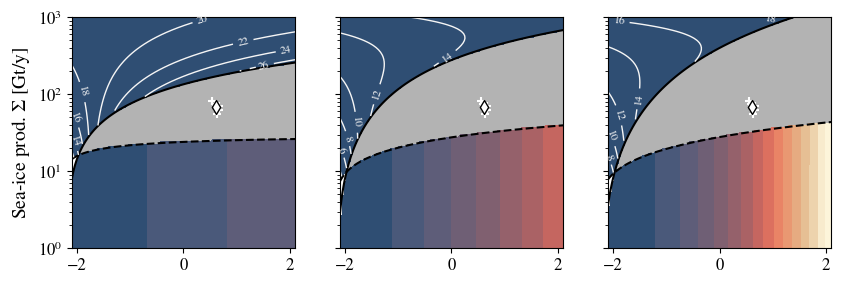

In [8]:
fig, ax = plt.subplots(1,3,figsize=(9.8,3),sharey=True)

####################################################
#      Different cavity parameterisations plot     #
####################################################


Npoint = 100

SeaIce_list = np.logspace(0,3,Npoint) #Gt/y
Ap_list = SeaIce_list/Omega_ref/rho_i *1e12/3600/24/365.25 #m^2

T0_list = np.linspace(-2.1,2.1,Npoint)

for i,BoxModel,arguments in zip(np.arange(3),[fbm_qcst.BoxModel_qcst,fbm.BoxModel,fbm_velo.BoxModel_velo],[arguments_qcst,arguments_PICO,arguments_velo]):

    melt_d, melt_c, sigma_d, sigma_c, stability_d, stability_c, bistable = melt_map(BoxModel, arguments, Ap_list, T0_list, max_iter=200, random_step=0.1)

    print(BoxModel)
    Apbmin, Apbmax, delta_Ap = bistable_size(bistable,T0_list,T0_ref,Ap_list)
    print(delta_Ap*rho_i*Omega_ref*24*3600*365.25/1e12,'Gt/y')

    # compute basal mass losses
    melt_c = melt_c*12 *rho_i*Ac /1e12 # Gt/y
    melt_d = melt_d*12 *rho_i*Ac /1e12 # Gt/y

    # plot basal mass losses
    levels_d = np.arange(0,1601,100)
    melt_conv = ax[i].contourf(T0_list, SeaIce_list, melt_c,cmap=lipari_cut,vmin=0,vmax=1500, levels=levels_d)
    melt_diff = ax[i].contourf(T0_list, SeaIce_list, melt_d,cmap=lipari_cut,vmin=0,vmax=1500, levels=levels_d) 

    # plot bistable region
    ax[i].contourf(T0_list, SeaIce_list, bistable,cmap='binary',vmin=0,vmax=1,levels=np.linspace(0,1,6))

    # plot transition thresholds
    if np.max(sigma_d)>0:
        ax[i].contour(T0_list,SeaIce_list,sigma_d,colors='black',levels=0)
    if np.min(sigma_c)<0:
        ax[i].contour(T0_list,SeaIce_list,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    # scatter plot realistic forcings
    ax[i].scatter(T0_series,SeaIce_series,marker='+', c='white',zorder=3) 
    ax[i].scatter(T0_ref,np.mean(SeaIce_series),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1,zorder=3)

    # contour plot of the convective regime
    contour_c = np.ma.masked_where(stability_d==1,melt_c)
    cont_c = ax[i].contour(T0_list, SeaIce_list, contour_c, np.arange(0,30,2), colors='whitesmoke', linewidths=1.)

    ax[i].set_xlim((-2.1,2.1))
    ax[i].set_yscale('log')

    # label the convective contour plot
    ax[i].clabel(cont_c, fontsize=8)
    

ax[0].set_ylabel(r'Sea-ice prod. $\Sigma$'+' '+r'$\mathrm{[Gt/y]}$')

plt.savefig('Figures/Figure4/Fig4_1st_row.pdf', format='pdf',bbox_inches='tight')

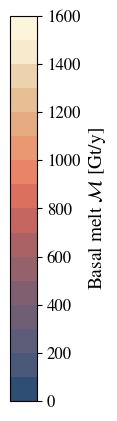

In [9]:
fig, ax = plt.subplots(figsize=(0.35, 5))

# Create a colorbar
cbar = plt.colorbar(melt_diff, cax=ax, orientation='vertical')
cbar.set_label(r'Basal melt $\mathcal{M}$ [Gt/y]')

# Show the plot
plt.savefig('Figures/Figure4/Fig4_colorbar.pdf', bbox_inches='tight')
plt.show()

### plots vertical mixing params

/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025/fct_BoxModel.py:44: RuntimeWarning: invalid value encountered in sqrt
  x0 = -g1[0]/(2*C*rho_star*(beta*s-alpha))+np.sqrt((g1[0]/(2*C*rho_star*(beta*s-alpha)))**2-g1[0]*T_st_0/(C*rho_star*(beta*s-alpha)))


0.15
73.49971308197871 Gt/y
0.3
3.4113246536498885 Gt/y
0.45
No bistability


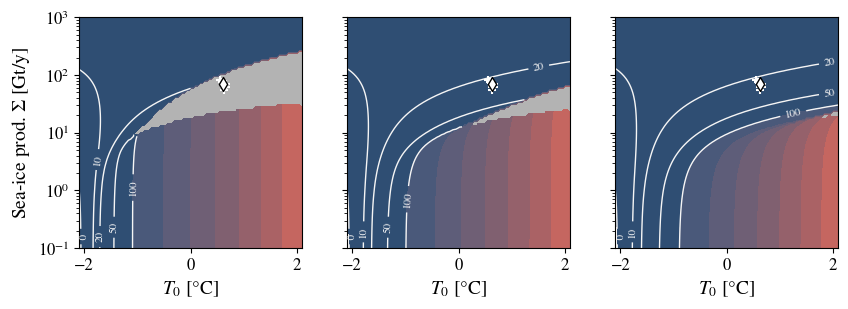

In [17]:
import imp
imp.reload(fbm)

########################################
#      smooth vertical mixing plot     #
########################################

fig, ax = plt.subplots(1,3,figsize=(9.8,3),sharey=True)

np.random.seed(464654) # This random seed works well here


Npoint = 100
SeaIce_list = np.logspace(-1,3,Npoint) #Gt/y
Ap_list = SeaIce_list/Omega_ref/rho_i *1e12/3600/24/365.25 #m^2

T0_list = np.linspace(-2.1,2.1,Npoint)


Lamb_list = [0.15,0.3,0.45]

for i,Lamb in zip(np.arange(3),Lamb_list):

    arguments = arguments_smooth
    arguments[10] = Lamb

    melt_fw, melt_bw, bistable, sigma_fw, sigma_bw = melt_map_smooth(arguments,Ap_list, T0_list, max_iter=400, random_step=0.5, tol=0.01)

    print(Lamb)
    try:
        Apbmin, Apbmax, delta_Ap = bistable_size(bistable,T0_list,T0_ref,Ap_list)
        print(delta_Ap*rho_i*Omega_ref*365.25*24*3600/1e12,'Gt/y')
    except:
        print('No bistability')
    


    # remove some numerical artifacts
    mask = bistable.mask.copy()
    # Create a condition for inner elements (avoid border columns)
    condition = (~bistable.mask[:, 1:-1]) & (bistable.mask[:, :-2]) & (bistable.mask[:, 2:])
    # Apply the condition
    mask[:, 1:-1][condition] = True
    bistable = np.ma.masked_where(mask,bistable)

    # compute and plot the basal mass loss
    melt = melt_fw*12 *rho_i*Ac /1e12# Gt/y
    levels_d = np.arange(0,1601,100)
    melt_mono = ax[i].contourf(T0_list, SeaIce_list, melt,cmap=lipari_cut,vmin=0,vmax=1500, levels=levels_d) 

    # plot the bistable region
    ax[i].contourf(T0_list, SeaIce_list, bistable,cmap='binary',vmin=0,vmax=1,levels=np.linspace(0,1,6))
    
    # scatter plot realistic forcings
    ax[i].scatter(T0_series,SeaIce_series,marker='+', c='white',zorder=3) # Ap in km²
    ax[i].scatter(T0_ref,np.mean(SeaIce_series),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1,zorder=3)
    
    ax[i].set_xlim((-2.1,2.1))

    ax[i].set_yscale('log')
    ax[i].set_xlabel(r'$T_0$'+' [°C]')

    # contour plot the low basal mass loss
    contour = np.ma.masked_where(~bistable.mask,melt)
    cont = ax[i].contour(T0_list, SeaIce_list, contour, np.array([0,10,20,50,100]), colors='whitesmoke', linewidths=1.)
    ax[i].clabel(cont, fontsize=8)

ax[0].set_ylabel(r'Sea-ice prod. $\Sigma$'+' '+r'$\mathrm{[Gt/y]}$')

plt.savefig('Figures/Figure4/Fig4_2nd_row.pdf',format='pdf', bbox_inches='tight')

plt.show()